In [2]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal

In [36]:
class QuadricInput(TypedDict):
    a: float
    b: float
    c: float
    equaction: str
    discriminant: float
    two_real_roots: tuple[float, float]
    one_real_root: float
    
    


In [30]:
def Show_Equation(data: QuadricInput):
    eqution=f"{data['a']}x^2 + {data['b']}x + {data['c']} = 0"
    return {"equaction": eqution}

In [49]:
def Discriment(data: QuadricInput):
    disc=(data['b']**2)- (4*data['a']*data['c'])
    return {"discriminant": disc}

In [50]:
def check_confition(data: QuadricInput) -> Literal["two_real_roots", "one_real_root", "no_real_roots"]:
    if data['discriminant'] > 0:
        return "two_real_roots"
    elif data['discriminant'] == 0:
        return "one_real_root"
    else:
        return "no_real_roots"

In [58]:
def two_real_roots(data: QuadricInput):
    root1 = (-data['b'] + data['discriminant']**0.5) / (2 * data['a'])
    root1=round(root1,3)
    root2 = (-data['b'] - data['discriminant']**0.5) / (2 * data['a'])
    root2=round(root2,3)
    return {"two_real_roots": (root1, root2)}

In [59]:
def one_real_root(data: QuadricInput):
    root = -data['b'] / (2 * data['a'])
    return {"one_real_root": root}

In [66]:
def no_real_roots(data: QuadricInput):
    return {"no_real_roots": f"There are noe real roots for the equation {data['equaction']}"}

In [67]:
graph = StateGraph(QuadricInput)

In [68]:
graph.add_node("Show_Equation", Show_Equation)
graph.add_node("Discriment", Discriment)
graph.add_node("two_real_roots", two_real_roots)
graph.add_node("one_real_root", one_real_root)
graph.add_node("no_real_roots", no_real_roots)

graph.add_edge(START, "Show_Equation")
graph.add_edge("Show_Equation", "Discriment")
graph.add_conditional_edges("Discriment", check_confition)
graph.add_edge("two_real_roots", END)
graph.add_edge("one_real_root", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()

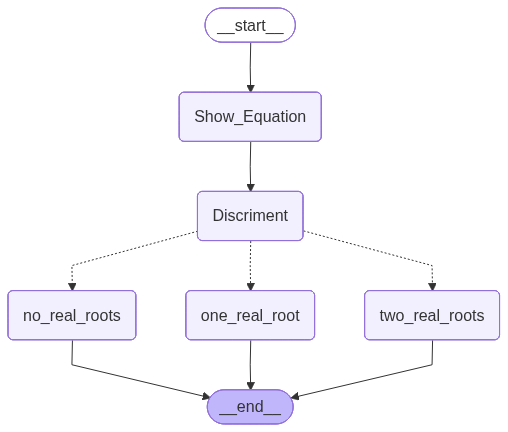

In [69]:
workflow

In [71]:
workflow.invoke({"a": 4, "b":3, "c": 2})

{'a': 4, 'b': 3, 'c': 2, 'equaction': '4x^2 + 3x + 2 = 0', 'discriminant': -23}